In [63]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import community as community_louvain

In [2]:
df = pd.read_csv('input_grafo.csv')
df_downgrades = df[
    df["evento_crediticio"] == "Downgrade"
]

In [3]:
df.head()

,source,periodo_mensual_A,target,evento_crediticio,weight
0,30500120882,2024-05,30509300700,Upgrade,0.301194
1,30500120882,2024-05,30525322749,Upgrade,0.165299
2,30500120882,2024-05,30525698412,Upgrade,0.135335
3,30500120882,2024-05,30526552659,Upgrade,0.301194
4,30500120882,2024-05,30576721710,Upgrade,0.449329


Nodos: 50 | Aristas: 2030


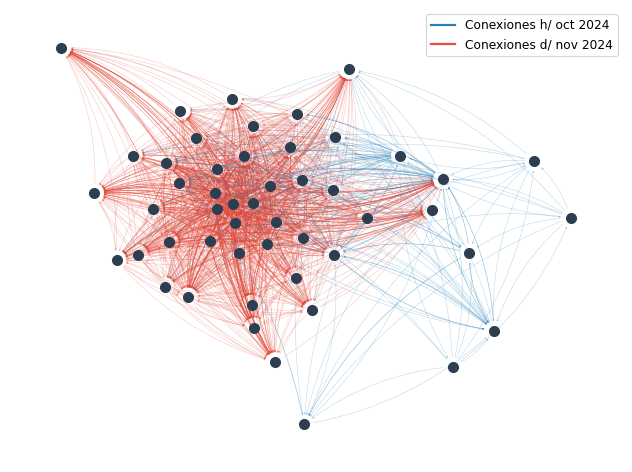

In [28]:
# 1. Crear el MULTIGRAFO DIRIGIDO (Soporta múltiples flechas A -> B)
G_multi = nx.from_pandas_edgelist(
    df_downgrades,
    source="source",
    target="target",
    edge_attr=["weight", "periodo_mensual_A", "evento_crediticio"],
    create_using=nx.MultiDiGraph(),
)

# 2. Clasificar los múltiples enlaces por periodo
edge_colors = []
for u, v, k, data in G_multi.edges(keys=True, data=True):
    fecha = data.get("periodo_mensual_A")

    if int(str(fecha).replace("-", "")[:6]) <= 202410:
        edge_colors.append("#2980b9")  # Época 1: Azul
    else:
        edge_colors.append("#e74c3c")  # Época 2: Rojo

print(f"Nodos: {G_multi.number_of_nodes()} | Aristas: {G_multi.number_of_edges()}")

# =====================================================================
# VISUALIZACIÓN DEL MULTIGRAFO
# =====================================================================
plt.figure(figsize=(8, 6), dpi=80)

pos_multi = nx.spring_layout(G_multi, k=0.7, seed=42)
nx.draw_networkx_nodes(
    G_multi, pos_multi, node_size=80, node_color="#2c3e50", alpha=1
)

nx.draw_networkx_edges(
    G_multi,
    pos_multi,
    edge_color=edge_colors,
    width=0.5,
    alpha=0.3,
    arrowsize=3,
    connectionstyle="arc3,rad=0.15",
)

proxies = [
    plt.Line2D([0], [0], color="#2980b9", lw=2),
    plt.Line2D([0], [0], color="#e74c3c", lw=2),
]
plt.legend(
    proxies,
    ["Conexiones h/ oct 2024", "Conexiones d/ nov 2024"],
    loc="upper right",
    frameon=True,
    fontsize=11,
)
plt.axis("off")
plt.tight_layout()
plt.show()

Nodos totales: 50
Enlaces Azules: 241 | Enlaces Rojos: 1789


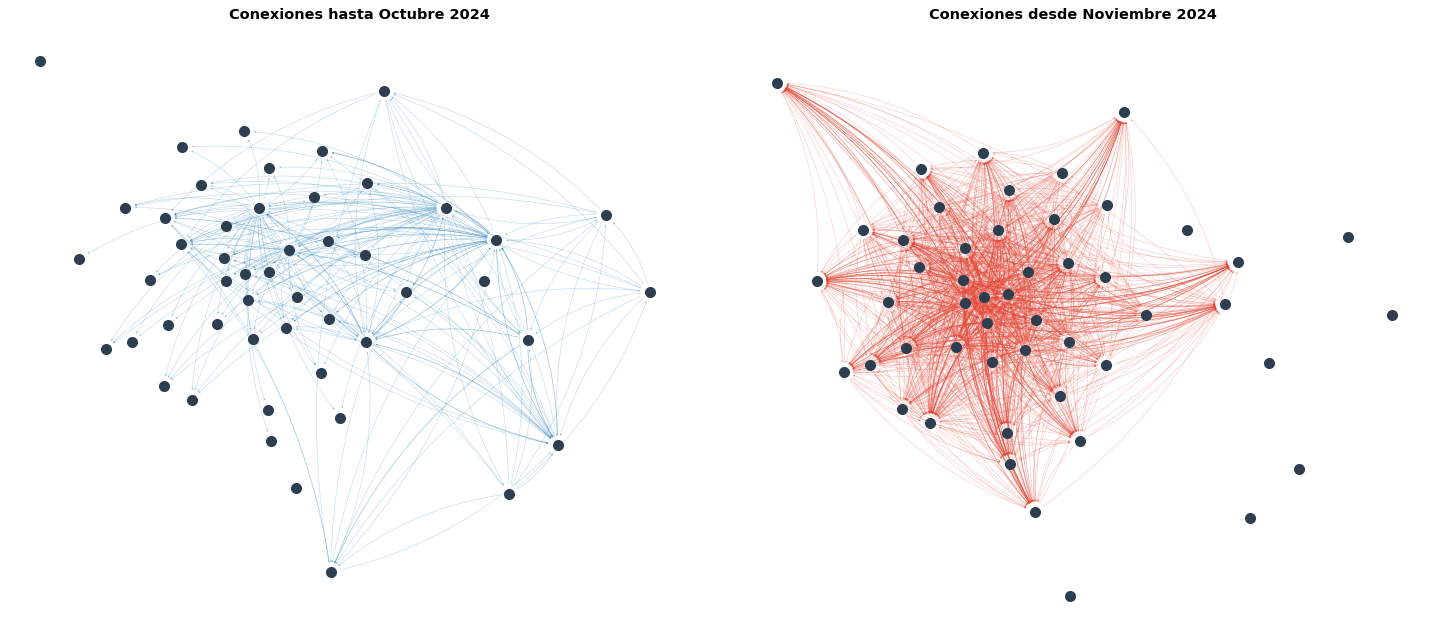

In [29]:
# 1. Crear el MULTIGRAFO DIRIGIDO
G_multi = nx.from_pandas_edgelist(
    df_downgrades,
    source="source",
    target="target",
    edge_attr=["weight", "periodo_mensual_A", "evento_crediticio"],
    create_using=nx.MultiDiGraph(),
)

# 2. CREAR DOS SUBGRAFOS INDEPENDIENTES
G_azul = nx.MultiDiGraph()
G_azul.add_nodes_from(G_multi.nodes(data=True))

G_rojo = nx.MultiDiGraph()
G_rojo.add_nodes_from(G_multi.nodes(data=True))

for u, v, k, data in G_multi.edges(keys=True, data=True):
    fecha = data.get("periodo_mensual_A")

    if int(str(fecha).replace("-", "")[:6]) <= 202410:
        G_azul.add_edge(u, v, key=k, **data)  # Época 1: Azul
    else:
        G_rojo.add_edge(u, v, key=k, **data)  # Época 2: Rojo

print(f"Nodos totales: {G_multi.number_of_nodes()}")
print(f"Enlaces Azules: {G_azul.number_of_edges()} | Enlaces Rojos: {G_rojo.number_of_edges()}")

# =====================================================================
# VISUALIZACIÓN EN PARALELO
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), dpi=80)
pos_multi = nx.spring_layout(G_multi, k=0.7, seed=42)

# --- 1. GRÁFICO IZQUIERDO: SOLO ENLACES AZULES ---
nx.draw_networkx_nodes(
    G_azul, pos_multi, node_size=80, node_color="#2c3e50", alpha=1, ax=ax1
)
nx.draw_networkx_edges(
    G_azul,
    pos_multi,
    edge_color="#2980b9",
    width=0.5,
    alpha=0.3,
    arrowsize=3,
    connectionstyle="arc3,rad=0.15",
    ax=ax1,
)
ax1.set_title("Conexiones hasta Octubre 2024", fontsize=13, fontweight="bold", pad=15)
ax1.axis("off")

# --- 2. GRÁFICO DERECHO: SOLO ENLACES ROJOS ---
nx.draw_networkx_nodes(
    G_rojo, pos_multi, node_size=80, node_color="#2c3e50", alpha=1, ax=ax2
)
nx.draw_networkx_edges(
    G_rojo,
    pos_multi,
    edge_color="#e74c3c",
    width=0.5,
    alpha=0.3,
    arrowsize=3,
    connectionstyle="arc3,rad=0.15",
    ax=ax2,
)
ax2.set_title("Conexiones desde Noviembre 2024", fontsize=13, fontweight="bold", pad=15)
ax2.axis("off")

plt.tight_layout()
plt.show()

Dimensiones de la matriz: (50, 50)


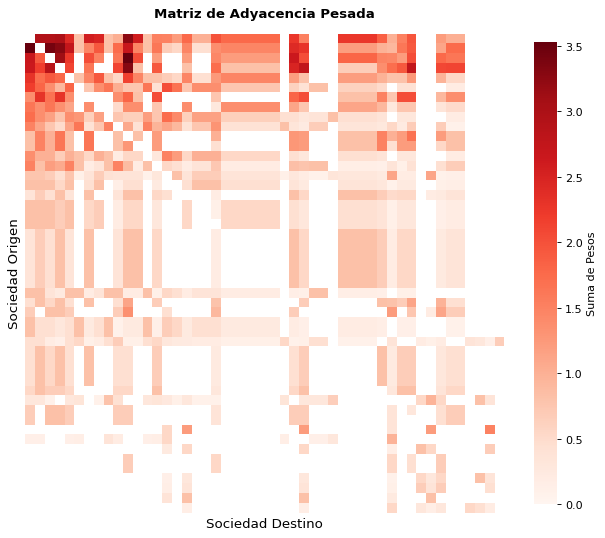

In [40]:
matriz_adyacencia = nx.to_pandas_adjacency(G_multi, weight="weight")
matriz_adyacencia = matriz_adyacencia.fillna(0.0)
print(f"Dimensiones de la matriz: {matriz_adyacencia.shape}")

orden_sources = df_downgrades.groupby("source")["weight"].sum()
nodos_ordenados = orden_sources.sort_values(ascending=False).index
matriz_ordenada = matriz_adyacencia.reindex(
    index=nodos_ordenados, columns=nodos_ordenados, fill_value=0.0
)

mascara_ceros = matriz_ordenada == 0.0

plt.figure(figsize=(8, 8), dpi=80)

# Graficar el Heatmap
sns.heatmap(
    matriz_ordenada,
    mask=mascara_ceros,
    cmap="Reds",
    # vmax=1.0,
    vmin=0.0,
    square=True,
    cbar_kws={
        "label": "Suma de Pesos",
        "shrink": 0.75,
    },
    xticklabels=False,
    yticklabels=False,
)
# 5. Detalles estéticos
plt.title(
    "Matriz de Adyacencia Pesada",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Sociedad Destino", fontsize=12)
plt.ylabel("Sociedad Origen", fontsize=12)

plt.tight_layout()
plt.show()
plt.close()

In [44]:
es_fuertemente_conexa = nx.is_strongly_connected(G_multi)
print(f"¿La red de Downgrades es fuertemente conexa?: {es_fuertemente_conexa}")

¿La red de Downgrades es fuertemente conexa?: False


Nodos en toda la red: 50
Enlaces en toda la red (Eventos totales): 2030
Grado de Salida Medio: 40.60
Grado de Entrada Medio: 40.60
Clustering promedio Dirigido (Fagiolo, 2007): 0.6590


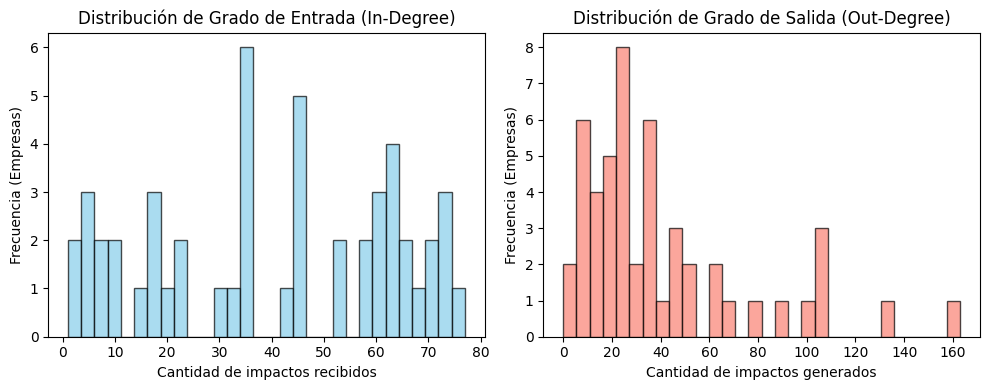

In [45]:
# ---------------------------------------------------------------------
# 2. Descripción del dataset (Métricas estructurales sobre Multigrafo)
# ---------------------------------------------------------------------
print(f"Nodos en toda la red: {G_multi.number_of_nodes()}")
print(f"Enlaces en toda la red (Eventos totales): {G_multi.number_of_edges()}")

# 1. Grado de Salida Medio (Out-Degree): Cuántos impactos genera una empresa en promedio
out_grados = dict(G_multi.out_degree()).values()
out_grado_medio = sum(out_grados) / len(out_grados)

# 2. Grado de Entrada Medio (In-Degree): Cuántos impactos recibe una empresa en promedio
in_grados = dict(G_multi.in_degree()).values()
in_grado_medio = sum(in_grados) / len(in_grados)

print(f"Grado de Salida Medio: {out_grado_medio:.2f}")
print(f"Grado de Entrada Medio: {in_grado_medio:.2f}")

# =====================================================================
# Clustering Promedio DIRIGIDO (Fagiolo, 2007)
# =====================================================================

# Se pasa de un multigrafo a un grafo simple (pero sigue siendo dirigido y pesado)
G_simple = nx.DiGraph(G_multi)

clustering_prom_dir = nx.average_clustering(G_simple)
print(f"Clustering promedio Dirigido (Fagiolo, 2007): {clustering_prom_dir:.4f}")

# ---------------------------------------------------------------------
# Visualización de las Distribuciones de Grado
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.hist(in_grados, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Grado de Entrada (In-Degree)')
plt.xlabel('Cantidad de impactos recibidos')
plt.ylabel('Frecuencia (Empresas)')

plt.subplot(122)
plt.hist(out_grados, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.title('Distribución de Grado de Salida (Out-Degree)')
plt.xlabel('Cantidad de impactos generados')
plt.ylabel('Frecuencia (Empresas)')

plt.tight_layout()
plt.show()

In [46]:
# Encontrar el nodo con el out-degree máximo
nodo_max, grado_max = max(G_multi.out_degree(), key=lambda x: x[1])

print(f"La empresa con más impactos generados es: {nodo_max} (Grado: {grado_max})")

La empresa con más impactos generados es: 33711944899 (Grado: 163)


In [47]:
# Contar conexiones repetidas vs vecinos únicos
vecinos_unicos = list(G_multi.successors(nodo_max))
print(f"Afectó a {len(vecinos_unicos)} empresas únicas.")
print(f"Promedio de impactos por empresa afectada: {grado_max / len(vecinos_unicos):.1f} veces.")

Afectó a 39 empresas únicas.
Promedio de impactos por empresa afectada: 4.2 veces.


In [61]:
# =====================================================================
# FUNCIÓN DE COMPARACIÓN ADAPTADA A REDES DIRIGIDAS
# =====================================================================
def compare_properties(graphs, labels):
    results = []
    for g, l in zip(graphs, labels):
        # Coeficiente de clustering dirigido nativo (Fagiolo, 2007)
        c_clustering = nx.average_clustering(g)

        # Distancia media adaptada a las restricciones de red dirigida
        try:
            if nx.is_strongly_connected(g):
                # Si es fuertemente conexo, calcula la distancia global real
                avg_path = nx.average_shortest_path_length(g)
            else:
                # Si no lo es (como los modelos teóricos), mide el núcleo central (SCC)
                componentes = max(nx.strongly_connected_components(g), key=len)
                subgrafo_nucleo = g.subgraph(componentes)

                if subgrafo_nucleo.number_of_nodes() > 1:
                    avg_path = nx.average_shortest_path_length(subgrafo_nucleo)
                else:
                    avg_path = np.nan
        except (nx.NetworkXError, nx.NetworkXNoPath):
            avg_path = np.nan

        results.append(
            {
                "Modelo": l,
                "C. clustering": c_clustering,
                "Distancia media": avg_path,
            }
        )
    return pd.DataFrame(results)

n = G_simple.number_of_nodes()
m = G_simple.number_of_edges()

k_avg_dirigido = m / n

# =====================================================================
# 2. GENERACIÓN DE PROTOTIPOS TEÓRICOS DIRIGIDOS
# (NO SE USAN PESOS EN ESTOS MODELOS)
# =====================================================================
# Erdős-Rényi (Modelo Nulo Estructural)
ER = nx.gnm_random_graph(n, m, directed=True, seed=42)

# Watts-Strogatz (Mundo Pequeño Dirigido)
k_ws = int(k_avg_dirigido) if int(k_avg_dirigido) % 2 == 0 else int(k_avg_dirigido) + 1
k_ws = max(2, k_ws)
WS = nx.watts_strogatz_graph(n, k_ws, 0.1, seed=42).to_directed()

# Barabási-Albert (Escala Libre Dirigida)
BA_grafo= nx.scale_free_graph(n, alpha=0.41, beta=0.54, gamma=0.05, seed=42)
BA = nx.DiGraph(BA_grafo)
if BA.number_of_nodes() > n:
    BA = BA.subgraph(list(G_simple.nodes()))

# =====================================================================
# 3. EJECUCIÓN DE LA COMPARACIÓN METODOLÓGICA
# =====================================================================
models = [G_simple, ER, WS, BA]
labels = [
    "Grafo Simple",
    "Erdős-Rényi",
    "Watts-Strogatz",
    "Barabási-Albert"
]

comparison_df = compare_properties(models, labels)

In [62]:
comparison_df

,Modelo,C. clustering,Distancia media
0,Grafo Simple,0.659049,1.529337
1,Erdős-Rényi,0.507853,1.491429
2,Watts-Strogatz,0.613843,1.511020
3,Barabási-Albert,0.035568,1.333333


ANÁLISIS DE COMUNIDADES
Modularidad Louvain: 0.122
Número de comunidades: 3


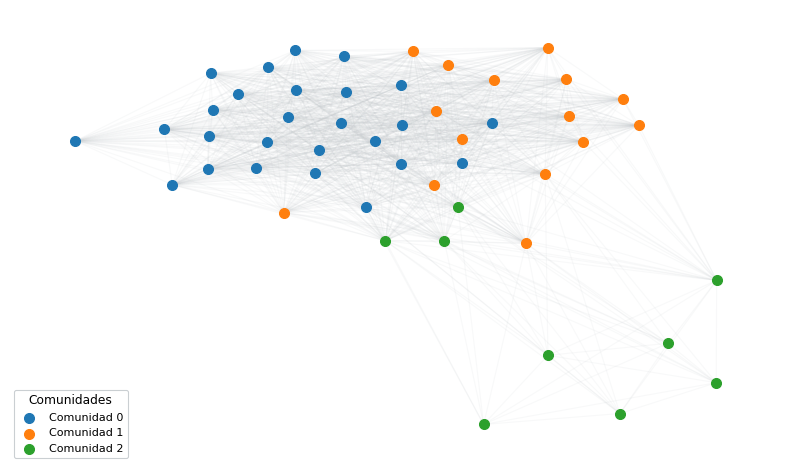

In [67]:
# Transformacion a no dirigido para Louvain
G_undir = G_simple.to_undirected()

# =====================================================================
# EJECUCIÓN DE LOUVAIN PONDERADO
# =====================================================================
partition = community_louvain.best_partition(G_undir, weight="weight", random_state=42)
modularity = community_louvain.modularity(partition, G_undir, weight="weight")

print("=" * 60)
print("ANÁLISIS DE COMUNIDADES")
print("=" * 60)
print(f"Modularidad Louvain: {modularity:.3f}")
print(f"Número de comunidades: {len(set(partition.values()))}")

# =====================================================================
# VISUALIZACIÓN DE LAS COMUNIDADES
# =====================================================================
plt.figure(figsize=(10, 6), dpi=80)

# Calculamos el layout de resortes
pos_comunidades = nx.spring_layout(G_undir, k=0.5, seed=42)

nx.draw_networkx_edges(
    G_undir,
    pos_comunidades,
    alpha=0.1,
    edge_color="#bdc3c7"
)

lista_comunidades = sorted(list(set(partition.values())))
mapa_colores = plt.cm.tab10

for i, com_id in enumerate(lista_comunidades):
    nodos_comunidad = [nodo for nodo, com in partition.items() if com == com_id]

    nx.draw_networkx_nodes(
        G_undir,
        pos_comunidades,
        nodelist=nodos_comunidad,
        node_size=80,
        node_color=[mapa_colores(i)],
        alpha=1,
        label=f"Comunidad {com_id}"
    )

plt.legend(
    title="Comunidades",
    title_fontsize=11,
    fontsize=10,
    loc="lower left",
    frameon=True,
    shadow=False,
    facecolor="white",
    edgecolor="#bdc3c7"
)
#
# plt.title(
#     "Detección de Comunidades Sectoriales de Riesgo Crítico (Algoritmo de Louvain)",
#     fontsize=13,
#     fontweight="bold",
#     pad=20,
# )
plt.axis("off")
plt.tight_layout()

plt.show()

In [68]:
actividades = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/actividades_economicas.csv")
actividades = actividades[actividades['es_actividad_principal'] == 1]
actividades['id_actividad'] = actividades['id_actividad'].astype(str).str.zfill(6)
actividades['grupo'] = actividades['id_actividad'].str[:2]
actividades['subgrupo'] = actividades['id_actividad'].str[:3]
clae = pd.read_csv("/Users/sofiascaiano/Documents/maestria/TT1/project/actividad_afip/data/output/clae_afip.csv")
clae['grupo'] = clae['grupo'].astype('Int64').astype(str).str.zfill(2)
clae['subgrupo'] = clae['subgrupo'].astype('Int64').astype(str).str.zfill(3)

In [70]:
actividades_2 = pd.merge(actividades, clae[clae['subgrupo'].isna()][['grupo', 'seccion', 'descripcion']], on='grupo', how='left', suffixes=('', '_grupo'))
actividades_3 = pd.merge(actividades_2, clae[~clae['subgrupo'].isna()][['subgrupo', 'descripcion']], on='subgrupo', how='left', suffixes=('', '_subgrupo'))
actividades_4 = pd.merge(actividades_3, clae[clae['grupo'].isna()][['seccion', 'descripcion']], on='seccion', how='left', suffixes=('', '_seccion'))
actividades_final = actividades_4[['cuit_consultado', 'id_actividad', 'descripcion', 'seccion', 'descripcion_grupo', 'descripcion_subgrupo', 'descripcion_seccion']]
actividades_final.columns = ['cuit', 'id_actividad', 'descripcion_actividad', 'seccion', 'descripcion_grupo', 'descripcion_subgrupo', 'descripcion_seccion']

In [71]:
actividades_final.descripcion_seccion.value_counts(dropna=False)

descripcion_seccion
INDUSTRIA MANUFACTURERA                                                                     52
SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO                                 25
EXPLOTACIÓN DE MINAS Y CANTERAS                                                             21
COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍCULOS AUTOMOTORES Y MOTOCICLETAS    15
SERVICIOS FINANCIEROS Y DE SEGUROS                                                          12
AGRICULTURA, GANADERÍA, CAZA, SILVICULTURA Y PESCA                                          11
CONSTRUCCIÓN                                                                                 7
INFORMACIÓN Y COMUNICACIONES                                                                 6
SERVICIO DE TRANSPORTE Y ALMACENAMIENTO                                                      4
SERVICIOS INMOBILIARIOS                                                                      3
SERVICIOS PROFESIONALES, CIENT

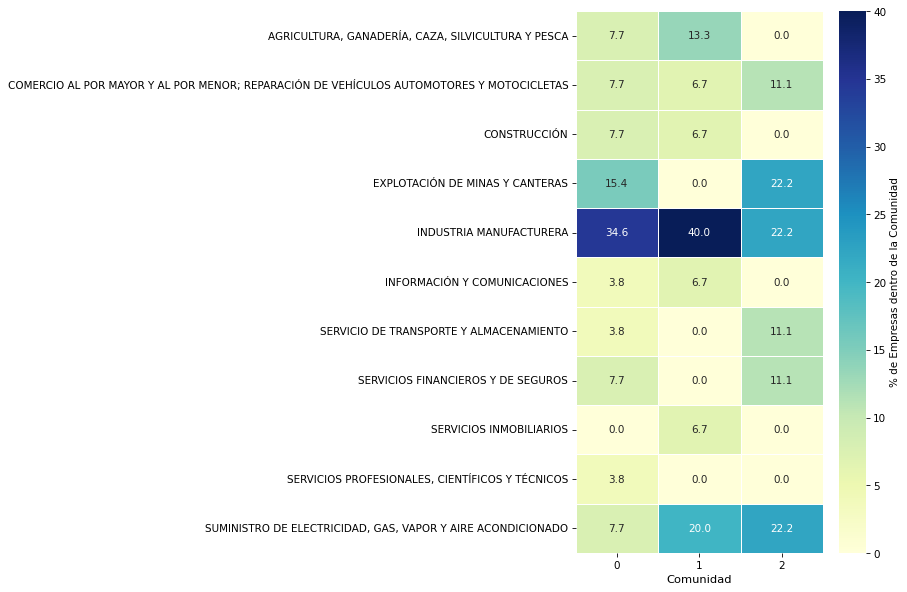

In [75]:
# =====================================================================
# MAPEO DE COMUNIDADES
# =====================================================================
df_louvain = pd.DataFrame(list(partition.items()), columns=['cuit', 'comunidad'])
df_louvain['cuit'] = df_louvain['cuit'].astype(str)
actividades_final['cuit'] = actividades_final['cuit'].astype(str)
df_analisis = df_louvain.merge(actividades_final, on='cuit', how='left')
df_analisis['descripcion_seccion'] = df_analisis['descripcion_seccion'].fillna('Sin Especificar')

# =====================================================================
# MATRIZ DE CONTINGENCIA (Frecuencias absolutas y relativas)
# =====================================================================
# Contamos cuántas empresas de cada sector cayeron en cada comunidad
matriz_contingencia = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    margins=True,
    margins_name="Total General"
)

# Calculamos los porcentajes por columna
matriz_porcentajes = pd.crosstab(
    df_analisis['descripcion_seccion'],
    df_analisis['comunidad'],
    normalize='columns'
) * 100

# =====================================================================
# VISUALIZACIÓN HEATMAP
# =====================================================================
plt.figure(figsize=(12, 8), dpi=75)
sns.heatmap(
    matriz_porcentajes,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': '% de Empresas dentro de la Comunidad'}
)

# plt.title("Perfil Sectorial de las Comunidades de Riesgo (Louvain)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Comunidad", fontsize=11)
plt.ylabel("", fontsize=11)
plt.tight_layout()

# Guardamos el PDF de alta calidad
# plt.savefig("composicion_sectorial_louvain.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [78]:
def calcular_debtrank_multigrafo(G_multi):
    """
    Calcula el DebtRank usando el Multigrafo histórico.
    El estrés se propaga acumulando la frecuencia e intensidad de los enlaces temporales.
    """
    nodos = list(G_multi.nodes())
    N = len(nodos)
    node_to_idx = {nodo: idx for idx, nodo in enumerate(nodos)}

    # Matriz de Adyacencia Ponderada a partir del Multigrafo
    A = np.zeros((N, N))

    # Recorremos todas las aristas temporales, se suman acumulando la fuerza del contagio histórico.
    for u, v, data in G_multi.edges(data=True):
        idx_u = node_to_idx[u]
        idx_v = node_to_idx[v]
        A[idx_u][idx_v] += data.get('weight', 1.0)

    # Normalizamos por el In-Degree total
    col_sums = A.sum(axis=0, keepdims=True)
    P = np.divide(A, col_sums, out=np.zeros_like(A), where=col_sums!=0)

    resultados_dr = {}

    # Simulación Dinámica
    for nodo_shock in nodos:
        idx_shock = node_to_idx[nodo_shock]

        # Vector de estrés h(t) de cada empresa (de 0 a 1)
        h = np.zeros(N)
        h[idx_shock] = 1.0  # Gatillo

        # Monitoreo de Estados (Sane=0, Distressed=1, Inactive=2)
        estado = np.zeros(N)
        estado[idx_shock] = 1

        paso = 0
        while np.any(estado == 1) and paso < N:
            activos = (estado == 1)
            nuevos_estreses = np.zeros(N)

            for j in range(N):
                if estado[j] == 0:  # Solo contagiamos a nodos que siguen "sanos"
                    # El estrés se transmite en función del peso acumulado en el multigrafo
                    impacto_acumulado = sum(h[i] * P[i][j] for i in range(N) if activos[i])
                    if impacto_acumulado > 0:
                        nuevos_estreses[j] = min(1.0, impacto_acumulado)

            # Transición de estados: los activos se apagan tras propagar su estrés
            estado[activos] = 2

            # Los alcanzados por el shock entran en estado crítico para la próxima ronda
            infectados_ronda = (nuevos_estreses > 0)
            estado[infectados_ronda] = 1
            h[infectados_ronda] = nuevos_estreses[infectados_ronda]

            paso += 1

        # Cuantificación del impacto neto en el resto de la red corporativa
        score_debtrank = sum(h) - 1.0

        # Lo expresamos como el % del mercado total que se degrada por culpa de este nodo
        resultados_dr[nodo_shock] = (score_debtrank / (N - 1)) * 100

    return resultados_dr

# =====================================================================
# EJECUCIÓN
# =====================================================================
scores_debtrank = calcular_debtrank_multigrafo(G_multi)
df_debtrank = pd.DataFrame(list(scores_debtrank.items()), columns=['cuit', 'DebtRank_Porcentaje'])
df_debtrank['cuit'] = df_debtrank['cuit'].astype(str)
actividades_final['cuit'] = actividades_final['cuit'].astype(str)
df_debtrank_final = df_debtrank.merge(actividades_final, on='cuit', how='left').sort_values(by='DebtRank_Porcentaje', ascending=False)

print("\n" + "="*75)
print("RANKING DE IMPACTO SISTÉMICO VÍA DEBTRANK (SOBRE ENLACES TEMPORALES)")
print("="*75)
print(df_debtrank_final[['cuit', 'DebtRank_Porcentaje', 'descripcion_seccion']].head(10).to_string(index=False))
print("="*75)


RANKING DE IMPACTO SISTÉMICO VÍA DEBTRANK (SOBRE ENLACES TEMPORALES)
       cuit  DebtRank_Porcentaje                                                                      descripcion_seccion
33711944899             7.721991                              SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO
30501062150             6.439637                                                                  INDUSTRIA MANUFACTURERA
30592724541             6.319659                                                                  INDUSTRIA MANUFACTURERA
30682434720             5.807197                              SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO
30589527115             5.527064                                                                  INDUSTRIA MANUFACTURERA
30714814229             5.333608                                                          EXPLOTACIÓN DE MINAS Y CANTERAS
30999027489             5.272752                              SUMINISTRO DE 

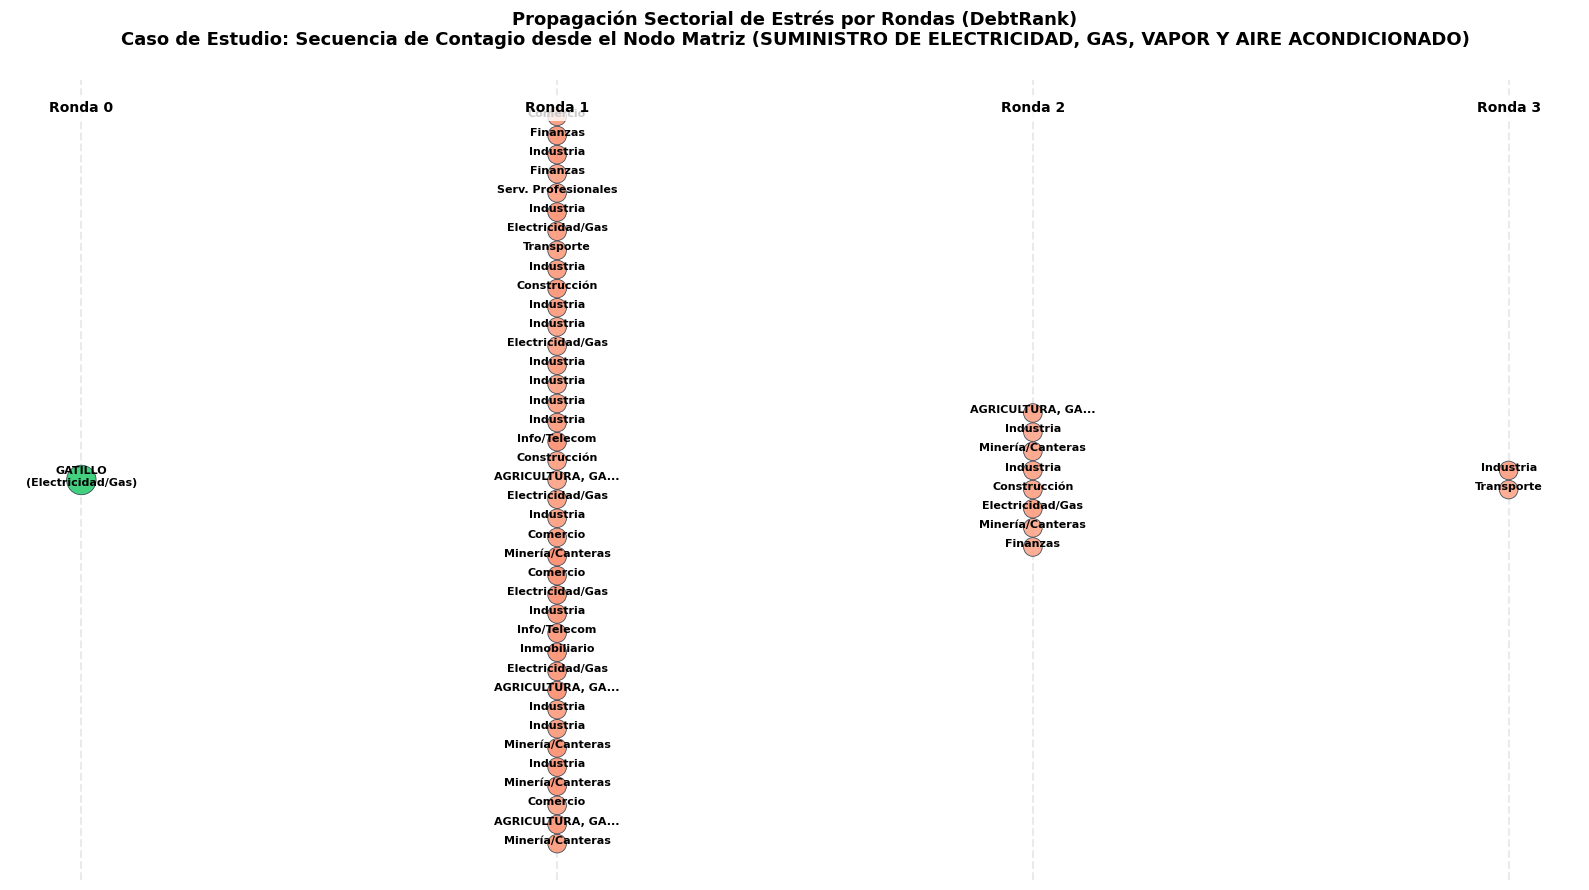

In [163]:
# =====================================================================
# 1. EJECUCIÓN DE LA AUDITORÍA TEMPORAL (OBTENER EL DATAFRAME DE PASOS)
# =====================================================================
# Usamos la función 'auditar_secuencia_contagio' que corrimos en el paso anterior
# sobre tu CUIT número 1 del ranking (por ejemplo, el CUIT de Celulosa o Agrofina)
df_pasos = auditar_secuencia_contagio(G_multi, cuit_lider, actividades_final)

# =====================================================================
# 2. CONSTRUCCIÓN DEL SUBGRAFO DE PROPAGACIÓN JERÁRQUICO
# =====================================================================
# Creamos un nuevo DiGraph limpio para armar el árbol de la cascada
G_arbol = nx.DiGraph()

# Agregamos los nodos con el atributo del paso en el que cayeron
for idx, row in df_pasos.iterrows():
    G_arbol.add_node(
        row["cuit"],
        paso=int(row["Paso_Contagio"]),
        estres=float(row["Estrés_Recibido"]),
        sector=row["descripcion_seccion"],
    )

# Conectamos los nodos basándonos en la red real:
# Una flecha va de A a B si existe en G_multi Y además A cayó justo en el paso anterior a B
for u, v in G_multi.edges():
    if G_arbol.has_node(u) and G_arbol.has_node(v):
        paso_u = G_arbol.nodes[u]["paso"]
        paso_v = G_arbol.nodes[v]["paso"]
        # El estrés viaja cronológicamente hacia adelante
        if paso_v == paso_u + 1:
            G_arbol.add_edge(u, v)

# =====================================================================
# 3. DISEÑO DEL LAYOUT POR COLUMNAS (MÉTODO JERÁRQUICO POR PASOS)
# =====================================================================
pos_jerarquico = {}
# Agrupamos los nodos por su número de paso para calcular sus coordenadas Y
pasos_unicos = sorted(df_pasos["Paso_Contagio"].unique())

for paso in pasos_unicos:
    nodos_del_paso = [
        n for n, attr in G_arbol.nodes(data=True) if attr["paso"] == paso
    ]
    num_nodos = len(nodos_del_paso)

    for idx, nodo in enumerate(nodos_del_paso):
        # Coordenada X = El número de paso (avanza de izquierda a derecha)
        x = paso
        # Coordenada Y = Centrada verticalmente para que quede con forma de árbol/abanico
        y = idx - (num_nodos - 1) / 2.0 if num_nodos > 1 else 0.0
        pos_jerarquico[nodo] = (x, y)

# =====================================================================
# 4. MAPEO VISUAL DE COLORES, TAMAÑOS Y ETIQUETAS SECTORIALES
# =====================================================================
plt.figure(figsize=(16, 9), dpi=100) # Le damos un poquito más de ancho para las etiquetas de texto

node_colors = []
node_sizes = []
labels_sectores = {}

# Diccionario interno para mapear y abreviar nombres larguísimos de AFIP/CLAE
# Si tus nombres ya están limpios, podés omitir o adaptar este mapeo
abreviaciones = {
    "AGRICULTURA, GANADERÍA, CAZA, SILVICULTURE Y PESCA": "Agro",
    "INDUSTRIA MANUFACTURERA": "Industria",
    "SUMINISTRO DE ELECTRICIDAD, GAS, VAPOR Y AIRE ACONDICIONADO": "Electricidad/Gas",
    "COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍCULOS": "Comercio",
    "COMERCIO AL POR MAYOR Y AL POR MENOR; REPARACIÓN DE VEHÍCULOS AUTOMOTORES Y MOTOCICLETAS": "Comercio",
    "SERVICIO DE TRANSPORTE Y ALMACENAMIENTO": "Transporte",
    "SERVICIOS FINANCIEROS Y DE SEGUROS": "Finanzas",
    "EXPLOTACIÓN DE MINAS Y CANTERAS": "Minería/Canteras",
    "CONSTRUCCIÓN": "Construcción",
    "INFORMACIÓN Y COMUNICACIONES": "Info/Telecom",
    "SERVICIOS INMOBILIARIOS": "Inmobiliario",
    "SERVICIOS PROFESIONALES, CIENTÍFICOS Y TÉCNICOS": "Serv. Profesionales"
}

for n, attr in G_arbol.nodes(data=True):
    # 4.1 Configuración de colores y tamaños
    if attr["paso"] == 0:
        node_colors.append("#2ecc71")  # Verde esmeralda para el Paciente Cero
        node_sizes.append(450)
    else:
        node_colors.append(cm.Reds(0.3 + 0.7 * attr["estres"]))
        node_sizes.append(180)

    # 4.2 Construcción de la etiqueta limpia por sector
    sector_original = attr["sector"]
    # Buscamos si tenemos una abreviación guardada, si no, dejamos los primeros 15 caracteres
    sector_limpio = abreviaciones.get(sector_original, str(sector_original)[:15] + "...")

    # Armamos la etiqueta. Para el paciente cero podemos dejar una marca distintiva
    if attr["paso"] == 0:
        labels_sectores[n] = f"GATILLO\n({sector_limpio})"
    else:
        labels_sectores[n] = sector_limpio

# Dibujamos las aristas (flechas del dominó)
nx.draw_networkx_edges(
    G_arbol,
    pos_jerarquico,
    edge_color="#e74c3c",
    alpha=0.35,
    width=1.2,
    arrowsize=12,
    node_size=250,
)

# Dibujamos los nodos del árbol
nx.draw_networkx_nodes(
    G_arbol,
    pos_jerarquico,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9,
    edgecolors="#2c3e50",
    linewidths=0.6,
)

# Colocamos las nuevas etiquetas sectoriales desplazadas hacia arriba
# Incrementamos levemente el desplazamiento vertical (0.15) para dar aire al texto
pos_labels = {k: (v[0], v[1] + 0.15) for k, v in pos_jerarquico.items()}
nx.draw_networkx_labels(
    G_arbol,
    pos_labels,
    labels=labels_sectores,
    font_size=8,
    font_weight="bold",
    font_family="sans-serif"
)

# Dibujamos líneas guía verticales de fondo para identificar cada etapa de tiempo
for paso in pasos_unicos:
    plt.axvline(x=paso, color="#b2bec3", linestyle="--", alpha=0.3, zorder=0)
    plt.text(
        paso,
        plt.ylim()[1] * 0.92,
        f"Ronda {paso}",
        horizontalalignment="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

# Formateo estético final del lienzo
plt.title(
    f"Propagación Sectorial de Estrés por Rondas (DebtRank)\n"
    f"Caso de Estudio: Secuencia de Contagio desde el Nodo Matriz ({info_gatillo['descripcion_seccion']})",
    fontsize=13,
    fontweight="bold",
    pad=25,
)
plt.axis("off")
plt.tight_layout()

# Guardamos el PDF definitivo optimizado para la lectura de la tesis
plt.savefig(f"debtrank_arbol_sectorial_{cuit_lider}.pdf", bbox_inches="tight", dpi=300)
plt.show()